In [1]:
import os
import json
import base64
import sqlite3
from io import BytesIO
from dotenv import load_dotenv
from openai import OpenAI
import gradio as gr
from PIL import Image

In [ ]:

load_dotenv(override=True)

openai_api_key = os.getenv("OPENAI_API_KEY")
if openai_api_key:
    print(f"OpenAI API Key exists and begins {openai_api_key[:8]}")
else:
    print("OpenAI API Key not set")

MODEL = "gpt-4.1-mini"
openai = OpenAI()

DB = "prices.db"

OpenAI API Key exists and begins sk-proj-


In [3]:
system_message = """
You are a helpful assistant for an Airline called FlightAI.
Give short, courteous answers, no more than 1 sentence.
Always be accurate.

Whenever you call the booking tool, always include the Booking ID, the passenger name, and the destination in the answer.
For example: "Flight booked successfully for Muhammad Egbaria to London. Your booking ID is 3."


If booking is requested, call the appropriate tool.
If you don't know something, say so.
"""

In [4]:
# ==============================
# DATABASE INIT
# ==============================

def init_db():
    with sqlite3.connect(DB) as conn:
        cursor = conn.cursor()

        # Prices table
        cursor.execute("""
            CREATE TABLE IF NOT EXISTS prices (
                city TEXT PRIMARY KEY,
                price INTEGER
            )
        """)

        # Bookings table
        cursor.execute("""
            CREATE TABLE IF NOT EXISTS bookings (
                id INTEGER PRIMARY KEY AUTOINCREMENT,
                name TEXT,
                destination TEXT,
                date TEXT
            )
        """)

        conn.commit()

In [5]:
init_db()

In [6]:
# ==============================
# TOOL FUNCTIONS
# ==============================

def get_ticket_price(city):
    print(f"PRICE TOOL CALLED for {city}", flush=True)
    with sqlite3.connect(DB) as conn:
        cursor = conn.cursor()
        cursor.execute('SELECT price FROM prices WHERE city = ?', (city.lower(),))
        result = cursor.fetchone()
        return f"Ticket price to {city} is ${result[0]}" if result else "No price data available for this city"

In [7]:

def book_flight(name, destination_city, date):
    print(f"BOOKING TOOL CALLED for {name}", flush=True)
    with sqlite3.connect(DB) as conn:
        cursor = conn.cursor()
        cursor.execute(
            "INSERT INTO bookings (name, destination, date) VALUES (?, ?, ?)",
            (name, destination_city.lower(), date)
        )
        conn.commit()
        booking_id = cursor.lastrowid
        return f"Flight booked successfully. Your booking ID is {booking_id}."

In [8]:
def check_booking(booking_id):
    print(f"CHECK TOOL CALLED for {booking_id}", flush=True)
    with sqlite3.connect(DB) as conn:
        cursor = conn.cursor()
        cursor.execute(
            "SELECT name, destination, date FROM bookings WHERE id = ?",
            (booking_id,)
        )
        result = cursor.fetchone()

        if result:
            return f"Booking {booking_id}: {result[0]} to {result[1]} on {result[2]}."
        return "Booking not found."

In [9]:
def cancel_booking(booking_id):
    print(f"CANCEL TOOL CALLED for {booking_id}", flush=True)
    with sqlite3.connect(DB) as conn:
        cursor = conn.cursor()
        cursor.execute(
            "DELETE FROM bookings WHERE id = ?",
            (booking_id,)
        )
        conn.commit()

        if cursor.rowcount > 0:
            return f"Booking {booking_id} has been cancelled."
        return "Booking not found."

In [10]:
# ==============================
# TOOL DEFINITIONS
# ==============================

price_function = {
    "name": "get_ticket_price",
    "description": "Get the price of a return ticket to the destination city.",
    "parameters": {
        "type": "object",
        "properties": {
            "destination_city": {
                "type": "string",
                "description": "The city that the customer wants to travel to",
            },
        },
    "required": ["destination_city"],
    "additionalProperties": False
    }   
}

booking_function = {
    "name": "book_flight",
    "description": "Book a return flight.",
            "parameters": {
                "type": "object",
                "properties": {
                    "name": {"type": "string"},
                    "destination_city": {"type": "string"},
                    "date": {"type": "string"}
                },
                "required": ["name", "destination_city", "date"],
                "additionalProperties": False
            }
}

check_function = {
    "name": "check_booking",
    "description": "Check booking by ID.",
    "parameters": {
        "type": "object",
        "properties": {
            "booking_id": {"type": "integer"}
        },
        "required": ["booking_id"],
        "additionalProperties": False
    }
}

cancel_function = {
    "name": "cancel_booking",
    "description": "Cancel booking by ID.",
    "parameters": {
        "type": "object",
        "properties": {
            "booking_id": {"type": "integer"}
        },
        "required": ["booking_id"],
        "additionalProperties": False
    }
}




In [11]:
tools = [
        {"type": "function", "function": price_function},
        {"type": "function", "function": booking_function},
        {"type": "function", "function": check_function},
        {"type": "function", "function": cancel_function}
    ]   


In [12]:
def handle_tool_calls(message):
    responses = []
    cities = []

    for tool_call in message.tool_calls:
        args = json.loads(tool_call.function.arguments)

        if tool_call.function.name == "get_ticket_price":
            city = args.get('destination_city')
            cities.append(city)

            result = get_ticket_price(city)

        elif tool_call.function.name == "book_flight":
            result = book_flight(
                args.get("name"),
                args.get("destination_city"),
                args.get("date")
            )
            cities.append(args.get("destination_city"))

        elif tool_call.function.name == "check_booking":
            result = check_booking(args.get("booking_id"))

        elif tool_call.function.name == "cancel_booking":
            result = cancel_booking(args.get("booking_id"))

        responses.append({
            "role": "tool",
            "content": result,
            "tool_call_id": tool_call.id
        })

    return responses, cities

In [13]:
# ==============================
# IMAGE GENERATOR
# ==============================

def artist(city):
    image_response = openai.images.generate(
        model="dall-e-3",
        prompt=f"An image representing a vacation in {city}, showing tourist spots and everything unique about {city}, in a vibrant pop-art style",
        size="1024x1024",
        n=1,
        response_format="b64_json",
    )

    image_base64 = image_response.data[0].b64_json
    image_data = base64.b64decode(image_base64)
    return Image.open(BytesIO(image_data))

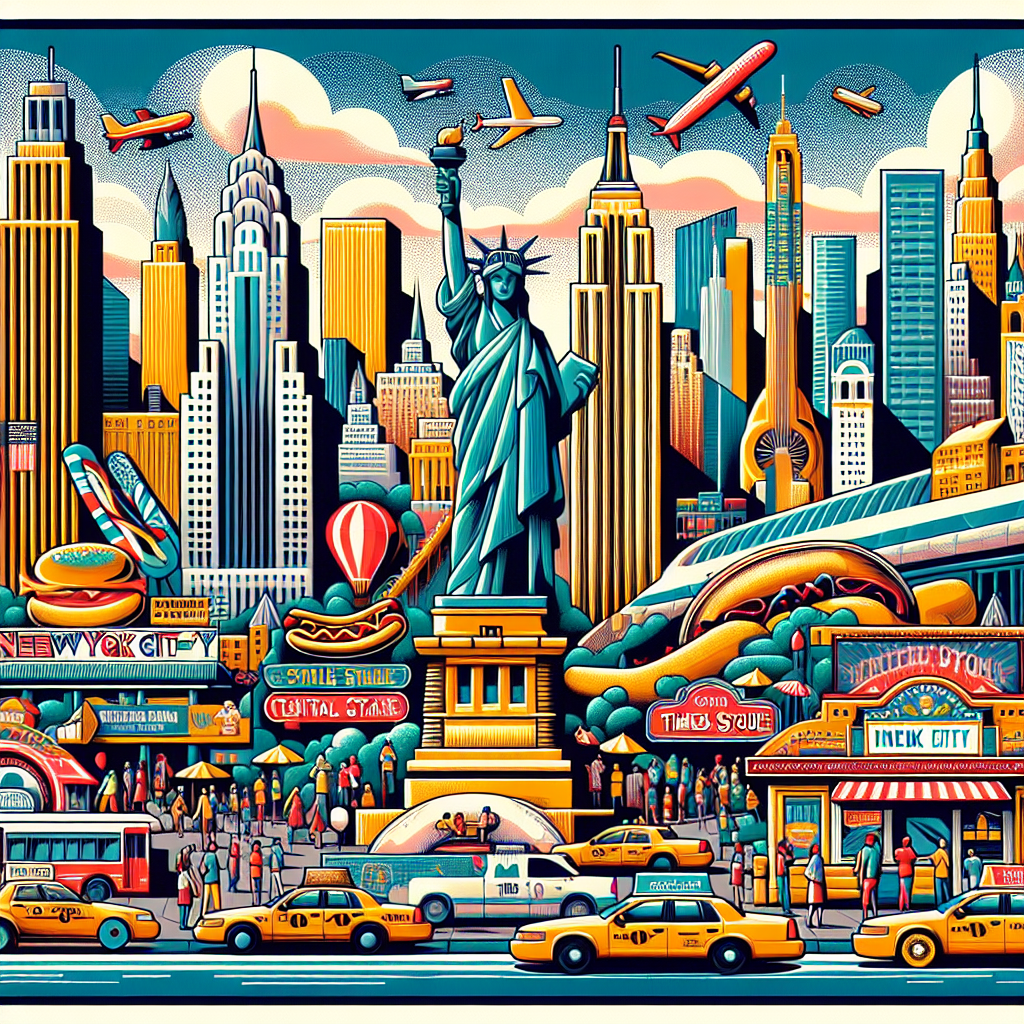

In [14]:
image = artist("New York City")
display(image)

In [15]:
# ==============================
# TEXT TO SPEECH
# ==============================

def talker(message):
    response = openai.audio.speech.create(
        model="gpt-4o-mini-tts",
        voice="onyx",
        input=message
    )
    return response.content

In [16]:
def chat(history):
    history = [{"role": h["role"], "content": h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history

    response = openai.chat.completions.create(
        model=MODEL,
        messages=messages,
        tools=tools
    )

    cities = []
    image = None

    while response.choices[0].finish_reason == "tool_calls":
        message = response.choices[0].message
        tool_responses, cities = handle_tool_calls(message)
        messages.append(message)
        messages.extend(tool_responses)

        response = openai.chat.completions.create(
            model=MODEL,
            messages=messages,
            tools=tools
        )

    reply = response.choices[0].message.content
    history += [{"role": "assistant", "content": reply}]

    voice = talker(reply)

    if cities:
        image = artist(cities[0])

    return history, voice, image

In [17]:
def set_ticket_price(city, price):
    with sqlite3.connect(DB) as conn:
        cursor = conn.cursor()
        cursor.execute('INSERT INTO prices (city, price) VALUES (?, ?) ON CONFLICT(city) DO UPDATE SET price = ?', (city.lower(), price, price))
        conn.commit()

In [18]:
ticket_prices = {"london":799, "paris": 899, "tokyo": 1420, "sydney": 2999, "rome": 800}
for city, price in ticket_prices.items():
    set_ticket_price(city, price)

In [19]:
def get_user_bookings():
    with sqlite3.connect(DB) as conn:
        cursor = conn.cursor()
        cursor.execute("SELECT id, name, destination, date FROM bookings ORDER BY id DESC")
        results = cursor.fetchall()

        return results

In [20]:
def get_available_destinations():
    with sqlite3.connect(DB) as conn:
        cursor = conn.cursor()
        cursor.execute("SELECT city FROM prices")
        cities = [row[0].capitalize() for row in cursor.fetchall()]
    return ", ".join(cities)

In [21]:
welcome_message = f"""
Hello! Welcome to FlightAI. You can check ticket prices, book a flight, check or cancel an existing booking.
Available destinations you can book: {get_available_destinations()}.
"""

initial_history = [{"role": "assistant", "content": welcome_message}]

In [23]:
# ==============================
# GRADIO UI
# ==============================

def put_message(message, history):
    return "", history + [{"role": "user", "content": message}]


with gr.Blocks() as ui:
    with gr.Row():
        chatbot = gr.Chatbot(value=initial_history,height=500, type="messages")
        image_output = gr.Image(height=500, interactive=False)

    with gr.Row():
        audio_output = gr.Audio(autoplay=True)

    with gr.Row():
        message = gr.Textbox(label="Chat with FlightAI:")
    
        # Booking table
    with gr.Row():
        booking_table = gr.DataFrame(
            headers=["ID", "Name", "Destination", "Date"],
            datatype=["number", "str", "str", "str"],
            interactive=False,
            label="Your Bookings"
        )

    message.submit(
        put_message,
        inputs=[message, chatbot],
        outputs=[message, chatbot]
    ).then(
        chat,
        inputs=chatbot,
        outputs=[chatbot, audio_output, image_output]
    ).then(
        get_user_bookings,
        inputs=[],
        outputs=[booking_table]
    )

ui.launch(inbrowser=True, auth=("Mu", "123"))

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


PRICE TOOL CALLED for Paris
BOOKING TOOL CALLED for Muhammad
BOOKING TOOL CALLED for John Smith
